In [1]:
import polars as pl
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
from matplotlib.patches import Patch

In [ ]:
benchmark_metrics = pl.read_parquet("/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/8_benchmark_part_two/cf_pdb_structure_similarity/both_parts_benchmark_structure_similarity.parquet")
benchmark_best_cp  = benchmark_metrics.sort(pl.col("CF_confidence"), descending=True).group_by("complex_ac").first()
benchmark_best_cp_bigger = benchmark_best_cp.filter(pl.col("n_proteins") > 2)

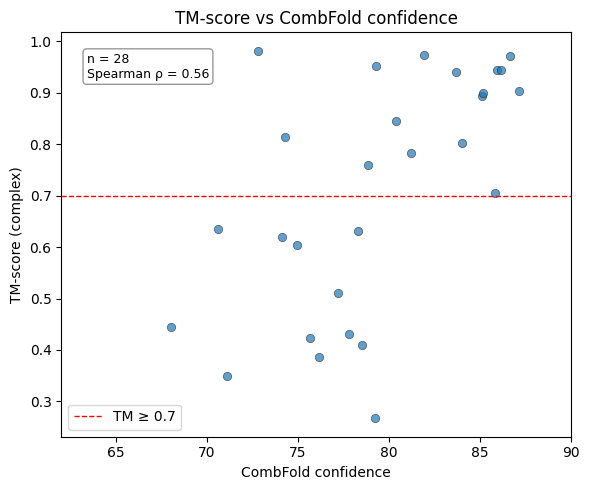

In [ ]:
#scatter plot of Tm score over the confidence
from scipy import stats

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    benchmark_best_cp_bigger["CF_confidence"],
    benchmark_best_cp_bigger["usalign_cpx_tm_score"],
    alpha=0.7, edgecolors="k", linewidths=0.4
)
ax.axhline(0.7, color="red", linestyle="--", linewidth=1, label="TM ≥ 0.7")
ax.set_xlabel("CombFold confidence")
ax.set_ylabel("TM-score (complex)")
ax.set_title("TM-score vs CombFold confidence")
ax.legend()

x = benchmark_best_cp_bigger["CF_confidence"].to_numpy()
y = benchmark_best_cp_bigger["usalign_cpx_tm_score"].to_numpy()
n = len(x)
spearman_r, spearman_p = stats.spearmanr(x, y)

ax.annotate(
    f"n = {n}\nSpearman ρ = {spearman_r:.2f}",
    xy=(0.05, 0.95), xycoords="axes fraction", va="top", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8)
)
plt.xlim(62, 90)
plt.tight_layout()
plt.show()

In [14]:
# how many of the complexes od i keep, hoq many have  tM over 0.7  and waht is the fraction
# 2. For each confidence threshold: n complexes kept, n with TM ≥ 0.7, fraction
thresholds = np.arange(0, 100, 5)

rows = []
for t in thresholds:
    kept = benchmark_best_cp_bigger.filter(pl.col("CF_confidence") >= t)
    n_kept = len(kept)
    n_good = kept.filter(pl.col("usalign_cpx_tm_score") >= 0.7).height
    rows.append({"threshold": t, "n_kept": n_kept, "n_tm_good": n_good, "fraction": n_good / n_kept if n_kept > 0 else None})

summary = pl.DataFrame(rows)
print(summary)

shape: (20, 4)
┌───────────┬────────┬───────────┬──────────┐
│ threshold ┆ n_kept ┆ n_tm_good ┆ fraction │
│ ---       ┆ ---    ┆ ---       ┆ ---      │
│ i64       ┆ i64    ┆ i64       ┆ f64      │
╞═══════════╪════════╪═══════════╪══════════╡
│ 0         ┆ 28     ┆ 16        ┆ 0.571429 │
│ 5         ┆ 28     ┆ 16        ┆ 0.571429 │
│ 10        ┆ 28     ┆ 16        ┆ 0.571429 │
│ 15        ┆ 28     ┆ 16        ┆ 0.571429 │
│ 20        ┆ 28     ┆ 16        ┆ 0.571429 │
│ …         ┆ …      ┆ …         ┆ …        │
│ 75        ┆ 21     ┆ 14        ┆ 0.666667 │
│ 80        ┆ 12     ┆ 12        ┆ 1.0      │
│ 85        ┆ 7      ┆ 7         ┆ 1.0      │
│ 90        ┆ 0      ┆ 0         ┆ null     │
│ 95        ┆ 0      ┆ 0         ┆ null     │
└───────────┴────────┴───────────┴──────────┘


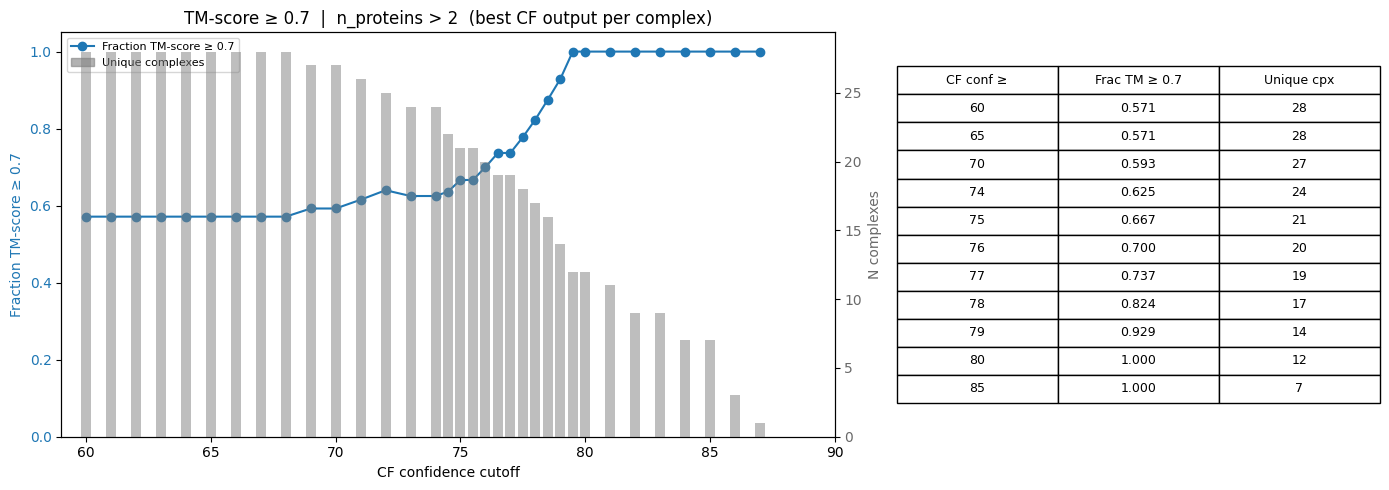

In [ ]:
TM_TARGET = 0.7
benchmark_best_cp_bigger = benchmark_best_cp.filter(pl.col("n_proteins") > 2)

def precision_vs_cutoff(df, metric_col, target, higher_is_better=True,
                        thresholds=np.arange(60, 90, 1)):
    rows = []
    for t in thresholds:
        sub = df.filter(pl.col('CF_confidence') >= t)
        n_out = len(sub)
        n_cpx = sub['complex_ac'].n_unique() if n_out > 0 else 0
        if n_out > 0:
            prec = float((sub[metric_col] >= target if higher_is_better
                          else sub[metric_col] <= target).mean())
        else:
            prec = None
        rows.append((t, prec, n_cpx, n_out))
    return rows

def add_plot(ax1, rows, ylabel, color):
    thresholds_v, precisions, n_complexes_v, n_outputs_v = zip(*rows)
    ax1.plot(thresholds_v, precisions, marker='o', color=color)
    ax1.set_xlabel('CF confidence cutoff')
    ax1.set_ylabel(ylabel, color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_ylim(0, 1.05)
    ax1.set_xlim(59, max(thresholds_v) + 1)
    ax2 = ax1.twinx()
    ax2.bar(thresholds_v, n_complexes_v, alpha=0.5, color='tab:grey', width=0.4)
    ax2.set_ylabel('N complexes', color='dimgray')
    ax2.tick_params(axis='y', labelcolor='dimgray')
    ax1.legend(handles=[
        plt.Line2D([0],[0], marker='o', color=color, label=ylabel),
        Patch(color='tab:grey', alpha=0.6, label='Unique complexes'),
    ], loc='upper left', fontsize=8)

def add_table(ax, rows, frac_label):
    lookup = {r[0]: r for r in rows}  # float keys
    cols = ['CF conf ≥', frac_label, 'Unique cpx']
    cells = []
    for t in [60, 65, 70, 74, 75, 76, 77, 78, 79, 80, 85]:
        r = lookup.get(t) or lookup.get(float(t))
        if r:
            prec = f'{r[1]:.3f}' if r[1] is not None else 'nan'
            cells.append([str(t), prec, str(r[2])])
    ax.axis('off')
    tab = ax.table(cellText=cells, colLabels=cols, cellLoc='center', loc='center')
    tab.auto_set_font_size(False)
    tab.set_fontsize(9)
    tab.scale(1, 1.6)

thresholds = np.concatenate([
    np.arange(60, 74, 1),
    np.arange(74, 80, 0.5),
    np.arange(80, 90, 1),
])

rows_tm = precision_vs_cutoff(benchmark_best_cp_bigger, 'usalign_cpx_tm_score', TM_TARGET,
                               thresholds=thresholds)

fig, (ax_plot, ax_tab) = plt.subplots(1, 2, figsize=(14, 5),
                                       gridspec_kw={'width_ratios': [1.6, 1]})
add_plot(ax_plot, rows_tm, f'Fraction TM-score ≥ {TM_TARGET}', 'tab:blue')
ax_plot.set_title(f'TM-score ≥ {TM_TARGET}  |  n_proteins > 2  (best CF output per complex)')
add_table(ax_tab, rows_tm, f'Frac TM ≥ {TM_TARGET}')
fig.tight_layout()
plt.show()